# Concept detection

Trains LR + XGBoost on CLIP activations per layer (10 bootstrap runs) to measure
how detectable `CONCEPT` is at each layer.

**Change only `CONCEPT`** — everything else follows automatically.

Outputs → `notebooks/results/single_debias/{CONCEPT}/concept_detection/`

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from xgboost import XGBClassifier
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

ROOT = Path.cwd()
for _ in range(6):
    if (ROOT / 'pyproject.toml').exists():
        break
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from software.metrics import get_metrics
from software.torch_lr import TorchLR
from software.viz import plot_concept_detection

In [2]:
import random, numpy as np, torch
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [3]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
CONCEPT        = 'eyeglasses'
NUM_LAYERS     = 24
RUNS_PER_LAYER = 10

# Solver for logistic regression probe:
#   'torch_lr' — TorchLR (LBFGS on GPU, stable, recommended)
#   'sgd'      — SGDClassifier from sklearn (stochastic gradient descent)
SOLVER   = 'torch_lr'
SOLVER_C = 0.1

METADATA_PATH   = ROOT / 'data' / 'metadata.csv'
ACTIVATIONS_DIR = ROOT / 'data' / 'activations' / 'raw'
OUT_DIR = ROOT / 'notebooks' / 'results' / 'single_debias' / CONCEPT / 'concept_detection'
OUT_DIR.mkdir(parents=True, exist_ok=True)

assert METADATA_PATH.exists(), f'Missing: {METADATA_PATH}'

meta = pd.read_csv(METADATA_PATH)[['filename', 'split', CONCEPT]]
assert CONCEPT in meta.columns, f'Column "{CONCEPT}" not in metadata.csv'

meta_train = meta[meta['split'] == 'train'][['filename', CONCEPT]]
meta_test  = meta[meta['split'] == 'test'][['filename',  CONCEPT]]

print(f'Concept  : {CONCEPT}')
print(f'Solver   : {SOLVER} (C={SOLVER_C})')
print(f'Train    : {len(meta_train)} images')
print(f'Test     : {len(meta_test)} images')
print(f'Output   : {OUT_DIR}')

Concept  : eyeglasses
Solver   : torch_lr (C=0.1)
Train    : 4642 images
Test     : 715 images
Output   : /workspace/WB2/notebooks/results/single_debias/eyeglasses/concept_detection


In [4]:
def make_clf(random_state=None):
    """Return logistic regression classifier based on SOLVER config."""
    if SOLVER == 'torch_lr':
        return TorchLR(C=SOLVER_C, max_iter=500, random_state=random_state)
    return SGDClassifier(
        loss='log_loss', penalty='l2',
        alpha=1.0 / (2.0 * SOLVER_C),
        max_iter=1000, tol=1e-4,
        random_state=random_state,
    )


def load_layer(split_label, layer_idx):
    """Returns (X: float32 array, y: int array) for the given split and layer."""
    path = ACTIVATIONS_DIR / split_label / f'layer_{layer_idx:02d}.parquet'
    assert path.exists(), f'Missing activations: {path}. Run 02_get_activations.ipynb first.'
    df = pd.read_parquet(path)
    meta_split = meta_train if split_label == 'train' else meta_test
    df = df.merge(meta_split, on='filename')
    feat_cols = [c for c in df.columns if c not in ('filename', CONCEPT)]
    return df[feat_cols].values.astype(np.float32), df[CONCEPT].astype(int).values

In [5]:
for layer in tqdm(range(NUM_LAYERS), desc='Layers'):
    X_train_full, y_train_full = load_layer('train', layer)
    X_test,       y_test       = load_layer('test',  layer)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_full)
    X_test_scaled  = scaler.transform(X_test)

    n_train = len(y_train_full)
    layer_results = []
    rng_layer = np.random.RandomState(layer + 1000)

    for run_id in tqdm(range(RUNS_PER_LAYER), desc=f'L{layer:02d}', leave=False):
        # Bootstrap with replacement; out-of-bag indices give an honest train metric.
        idx_b = np.random.RandomState(run_id).choice(n_train, size=n_train, replace=True)
        oob_mask = np.ones(n_train, dtype=bool)
        oob_mask[np.unique(idx_b)] = False
        X_b, y_b = X_train_scaled[idx_b], y_train_full[idx_b]
        X_oob, y_oob = X_train_scaled[oob_mask], y_train_full[oob_mask]
        use_oob = (len(y_oob) > 0) and (len(np.unique(y_oob)) == 2)

        models = {
            'LogisticRegression': make_clf(random_state=run_id),
            'XGBoost': XGBClassifier(
                n_estimators=100, max_depth=4, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8,
                tree_method='hist', device='cuda',
                random_state=run_id, eval_metric='logloss',
            ),
        }

        for model_name, model in models.items():
            model.fit(X_b, y_b)
            # Honest train metric on OOB samples (#7).
            if use_oob:
                tr_m = get_metrics(y_oob, model.predict(X_oob),
                                   model.predict_proba(X_oob)[:, 1])
            else:
                tr_m = get_metrics(y_b, model.predict(X_b),
                                   model.predict_proba(X_b)[:, 1])
            te_m = get_metrics(y_test, model.predict(X_test_scaled),
                               model.predict_proba(X_test_scaled)[:, 1])
            layer_results.append({
                'layer_id': layer, 'model': model_name, 'run_id': run_id,
                'method': 'real',
                **{f'train_{k}': v for k, v in tr_m.items()},
                **{f'test_{k}':  v for k, v in te_m.items()},
            })

        # ── #14 baselines: shuffled-labels + random-unit-vector CAV ──────
        y_shuffled = rng_layer.permutation(y_b)
        clf_shuf = make_clf(random_state=run_id)
        clf_shuf.fit(X_b, y_shuffled)
        if use_oob:
            tr_m = get_metrics(y_oob, clf_shuf.predict(X_oob),
                               clf_shuf.predict_proba(X_oob)[:, 1])
        else:
            tr_m = get_metrics(y_b, clf_shuf.predict(X_b),
                               clf_shuf.predict_proba(X_b)[:, 1])
        te_m = get_metrics(y_test, clf_shuf.predict(X_test_scaled),
                           clf_shuf.predict_proba(X_test_scaled)[:, 1])
        layer_results.append({
            'layer_id': layer, 'model': 'LogisticRegression', 'run_id': run_id,
            'method': 'random_shuffle',
            **{f'train_{k}': v for k, v in tr_m.items()},
            **{f'test_{k}':  v for k, v in te_m.items()},
        })

        d = X_train_scaled.shape[1]
        w_rand = rng_layer.randn(d).astype(np.float32)
        w_rand /= (np.linalg.norm(w_rand) + 1e-12)

        def _score(X):
            z = X @ w_rand
            p = 1.0 / (1.0 + np.exp(-z))
            return (z > 0).astype(int), p

        if use_oob:
            yhat_x, p_x = _score(X_oob); tr_m = get_metrics(y_oob, yhat_x, p_x)
        else:
            yhat_x, p_x = _score(X_b);   tr_m = get_metrics(y_b,   yhat_x, p_x)
        yhat_t, p_t = _score(X_test_scaled)
        te_m = get_metrics(y_test, yhat_t, p_t)
        layer_results.append({
            'layer_id': layer, 'model': 'LogisticRegression', 'run_id': run_id,
            'method': 'random_unit_vector',
            **{f'train_{k}': v for k, v in tr_m.items()},
            **{f'test_{k}':  v for k, v in te_m.items()},
        })

    pd.DataFrame(layer_results).to_csv(
        OUT_DIR / f'{layer:02d}_results.csv', index=False
    )

Layers:   0%|          | 0/24 [00:00<?, ?it/s]

L00:   0%|          | 0/10 [00:00<?, ?it/s]

L01:   0%|          | 0/10 [00:00<?, ?it/s]

L02:   0%|          | 0/10 [00:00<?, ?it/s]

L03:   0%|          | 0/10 [00:00<?, ?it/s]

...

L19:   0%|          | 0/10 [00:00<?, ?it/s]

L20:   0%|          | 0/10 [00:00<?, ?it/s]

L21:   0%|          | 0/10 [00:00<?, ?it/s]

L22:   0%|          | 0/10 [00:00<?, ?it/s]

L23:   0%|          | 0/10 [00:00<?, ?it/s]

## Visualization

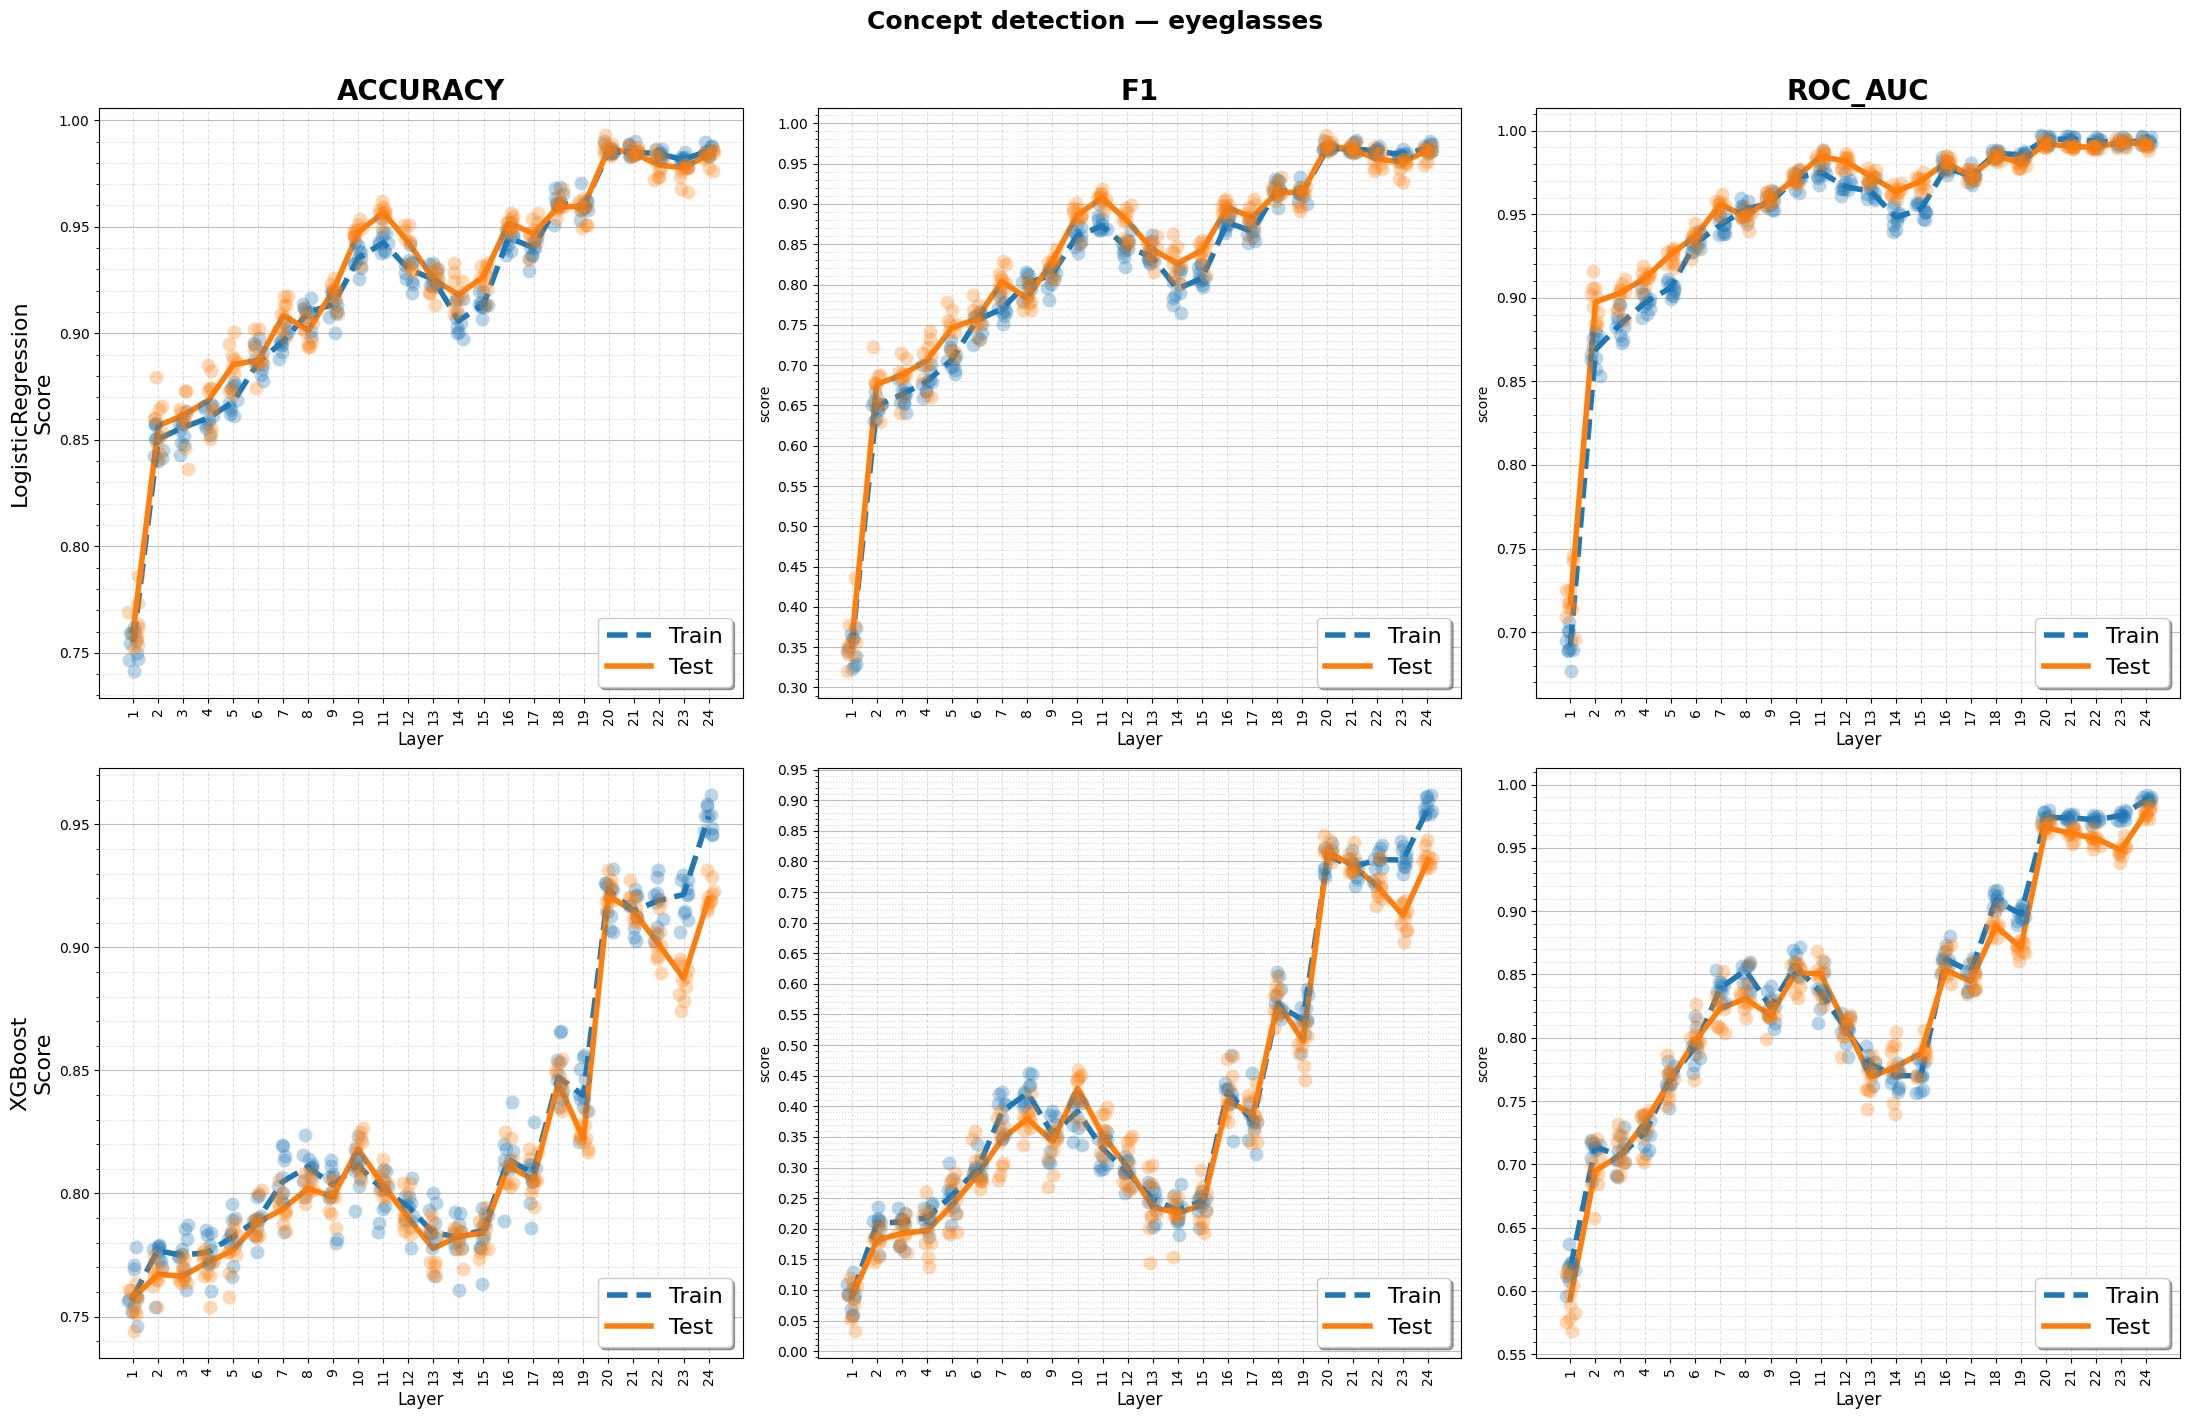

In [6]:
import glob

all_files = sorted(glob.glob(str(OUT_DIR / '*_results.csv')))
df_all = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True).sort_values('layer_id')

# Main figure shows 'real' method only; baselines are stored alongside.
df_real = df_all[df_all['method'] == 'real'] if 'method' in df_all.columns else df_all

# #5 — split metric column on the FIRST underscore so 'train_roc_auc' -> ('train','roc_auc').
metric_cols = [
    c for c in df_real.columns
    if (c.startswith('train_') or c.startswith('test_'))
    and c.split('_', 1)[1] not in ('recall', 'precision')
]
id_vars = [c for c in ['layer_id', 'model', 'run_id', 'method'] if c in df_real.columns]

df_melted = df_real.melt(id_vars=id_vars, value_vars=metric_cols,
                         var_name='metric_type', value_name='score')
df_melted['subset'] = df_melted['metric_type'].str.split('_', n=1).str[0]
df_melted['metric'] = df_melted['metric_type'].str.split('_', n=1).str[1]

plot_concept_detection(
    df_melted, CONCEPT,
    save_path=OUT_DIR / f'concept_detection_{CONCEPT}.png',
)